# Banking Fraud Detection — Baseline Models

This notebook trains basic machine learning models on the temporally separated training data and evaluates them on future transactions.

In [1]:
import pandas as pd

train_df = pd.read_csv("../data/train_temporal.csv")
test_df = pd.read_csv("../data/test_temporal.csv")

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


In [2]:
target = "is_fraud"

drop_columns = [
    "is_fraud",
    "transaction_id",
    "customer_id",
    "timestamp"
]

X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

Training features: (8000, 6)
Testing features: (2000, 6)


In [3]:
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "merchant_category",
    "customer_location",
    "device_type"
]

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

In [9]:
numerical_features = [
    "amount",
    "customer_age",
    "previous_transactions"
]

X_train_num = X_train[numerical_features].values
X_test_num = X_test[numerical_features].values

import numpy as np

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric="logloss"
    )
}

In [12]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

results = []

for name, model in models.items():

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)
    y_prob = model.predict_proba(X_test_final)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Precision,Recall,F1-Score,PR-AUC
0,Logistic Regression,0.0,0.0,0.0,0.022365
1,Random Forest,0.0,0.0,0.0,0.020838
2,XGBoost,0.0,0.0,0.0,0.026936


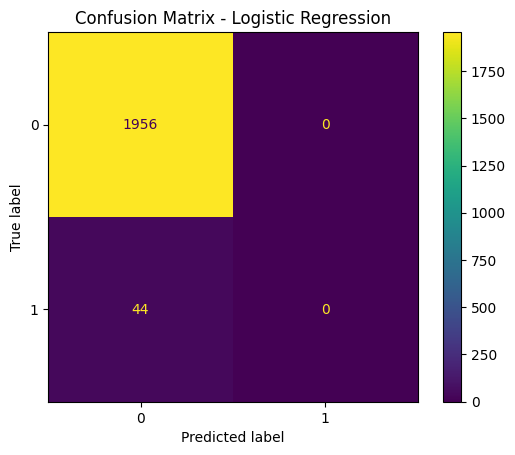

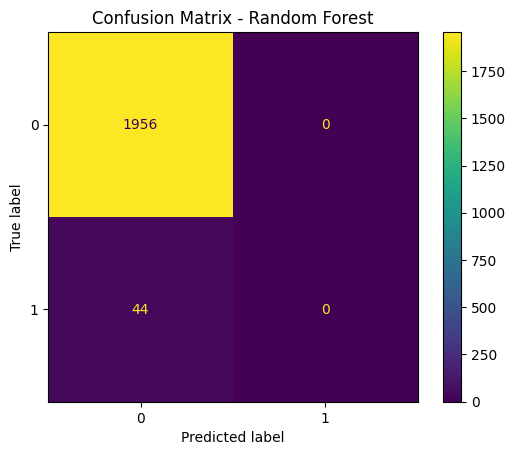

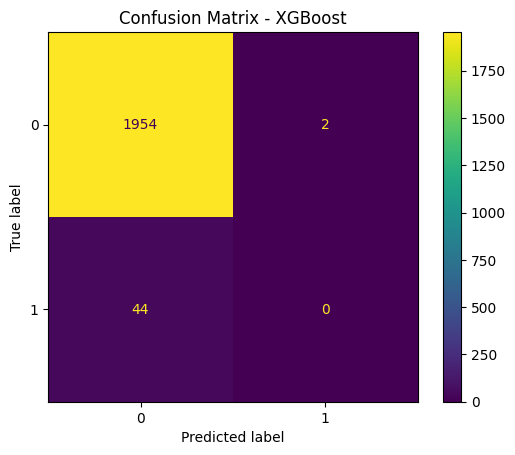

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():

    y_pred = model.predict(X_test_final)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

### Observations

- The three baseline models were trained using the original imbalanced training data.
- Their performance was evaluated on the future temporal test data.
- Precision, Recall, F1-Score and PR-AUC were used for comparison.
- These results provide the baseline for the SMOTE and cost-sensitive experiments.